# ISTVT — Preprocessing (FF++ Videos → Face Crops)

Converts  FaceForensics++ `.mp4` videos into aligned face-crop images.


```
original/        ← 1000 real videos    → becomes data/real/
Deepfakes/       ← 1000 fake videos    → becomes data/fake/
```



## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Install Dependencies

In [2]:
# Step 1 — Fix Pillow conflict first, then install facenet-pytorch
!pip install "Pillow<10.0.0" -q
!pip install facenet-pytorch -q
print("Done ✓")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.
Done ✓


In [3]:
# Reinstall compatible versions of torch and torchvision to resolve nms error
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cpu

print("Torch and Torchvision reinstalled successfully ✓")

Found existing installation: torch 2.2.0+cpu
Uninstalling torch-2.2.0+cpu:
  Successfully uninstalled torch-2.2.0+cpu
Found existing installation: torchvision 0.17.0+cpu
Uninstalling torchvision-0.17.0+cpu:
  Successfully uninstalled torchvision-0.17.0+cpu
Found existing installation: torchaudio 2.2.0+cpu
Uninstalling torchaudio-2.2.0+cpu:
  Successfully uninstalled torchaudio-2.2.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.2.0%2Bcpu-cp312-cp312-linux_x86_64.whl (186.7 MB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.17.0%2Bcpu-cp312-cp312-linux_x86_64.whl (1.6 MB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.2.0%2Bcpu-cp312-cp312-linux_x86_64.whl (1.7 MB)
Torch and Torchvision reinstalled successfully ✓


## Step 3 — Imports

In [4]:
import os, cv2, json, time
import numpy as np
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# OpenCV DNN face detector — no MTCNN needed
PROTOTXT_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
MODEL_URL    = "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20180205_fp16/res10_300x300_ssd_iter_140000_fp16.caffemodel"

!wget -q {PROTOTXT_URL} -O /tmp/deploy.prototxt
!wget -q {MODEL_URL}    -O /tmp/face_model.caffemodel

face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")
print(f"Device : {device}")
print("Face detector ready ✓")

Device : cpu
Face detector ready ✓


## Step 4 — Configure Paths


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xdxd003/ff-c23")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ff-c23' dataset.
Path to dataset files: /kaggle/input/ff-c23


In [7]:
# ── WHERE YOUR FF++ VIDEOS LIVE ─────────────────────────────────────────────
# If uploaded to Colab directly:
#   REAL_DIR = "/content/original"
#   FAKE_DIR = "/content/Deepfakes"
# If they are on Drive:
#   REAL_DIR = "/content/drive/MyDrive/FaceForensics/original"
#   FAKE_DIR = "/content/drive/MyDrive/FaceForensics/Deepfakes"

# ── KAGGLE PATHS ─────────────────────────────────────────────────────────────
REAL_DIR = "/kaggle/input/ff-c23/FaceForensics++_C23/original"
FAKE_DIR = "/kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes"

# ── OUTPUT (persists in Kaggle working dir) ───────────────────────────────────


OUT_DIR = "/content/drive/MyDrive/istvt_data"

# ── SETTINGS ─────────────────────────────────────────────────────────────────
MAX_VIDEOS      = 150
FRAMES_PER_VID  = 32
IMG_SIZE        = 128
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(os.path.join(OUT_DIR, "real"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "fake"), exist_ok=True)

print(f"Real videos dir : {REAL_DIR}")
print(f"Fake videos dir : {FAKE_DIR}")
print(f"Output dir      : {OUT_DIR}")
print(f"Max videos/class: {MAX_VIDEOS}")
print(f"Frames/video    : {FRAMES_PER_VID}")
print(f"Image size      : {IMG_SIZE}x{IMG_SIZE}")

Real videos dir : /kaggle/input/ff-c23/FaceForensics++_C23/original
Fake videos dir : /kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes
Output dir      : /content/drive/MyDrive/istvt_data
Max videos/class: 150
Frames/video    : 32
Image size      : 128x128


## Step 5 — Verify Folders

In [8]:
def list_videos(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.mp4', '.avi', '.mov'))
    ])

real_videos = list_videos(REAL_DIR)
fake_videos = list_videos(FAKE_DIR)

print(f"Real videos found : {len(real_videos)}")
print(f"Fake videos found : {len(fake_videos)}")
print(f"Sample real       : {real_videos[:3]}")
print(f"Sample fake       : {fake_videos[:3]}")

# Quick duration check on first video
cap   = cv2.VideoCapture(os.path.join(REAL_DIR, real_videos[0]))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps   = cap.get(cv2.CAP_PROP_FPS)
cap.release()
print(f"\nFirst video: {real_videos[0]}")
print(f"  Frames : {total}")
print(f"  FPS    : {fps:.1f}")
print(f"  Length : {total/fps:.1f}s")

Real videos found : 1000
Fake videos found : 1000
Sample real       : ['000.mp4', '001.mp4', '002.mp4']
Sample fake       : ['000_003.mp4', '001_870.mp4', '002_006.mp4']

First video: 000.mp4
  Frames : 396
  FPS    : 25.0
  Length : 15.8s


In [9]:
!pip install mtcnn

## Step 6 — Initialize MTCNN Face Detector

In [4]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(keep_all=False, device=device)
print("MTCNN ready ✓")

MTCNN ready ✓


## Step 7 — Core Functions
Face alignment exactly as described in the paper (Sec. IV-B.1):
> *"the tip of the nose as the center of the bounding box, and  
> 1.25 times the maximum height and width of the face"*


In [10]:
def detect_and_crop(frame_rgb, out_size=128, scale=1.25, conf_thresh=0.5):
    """
    OpenCV DNN face detector — drop-in replacement for MTCNN crop.
    Returns cropped face or None if no face found.
    """
    H, W = frame_rgb.shape[:2]
    blob  = cv2.dnn.blobFromImage(frame_rgb, 1.0, (300, 300),
                                   (104.0, 177.0, 123.0))
    face_net.setInput(blob)
    dets = face_net.forward()

    best_conf, best_box = 0, None
    for i in range(dets.shape[2]):
        conf = float(dets[0, 0, i, 2])
        if conf > conf_thresh and conf > best_conf:
            best_conf = conf
            x1 = int(dets[0, 0, i, 3] * W)
            y1 = int(dets[0, 0, i, 4] * H)
            x2 = int(dets[0, 0, i, 5] * W)
            y2 = int(dets[0, 0, i, 6] * H)
            best_box = (x1, y1, x2, y2)

    if best_box is None:
        return None

    x1, y1, x2, y2 = best_box
    cx   = (x1 + x2) // 2
    cy   = (y1 + y2) // 2
    side = int(scale * max(x2 - x1, y2 - y1) / 2)

    cx1 = max(0, cx - side)
    cy1 = max(0, cy - side)
    cx2 = min(W, cx + side)
    cy2 = min(H, cy + side)

    crop = frame_rgb[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, (out_size, out_size))


def process_one_video(video_path, out_dir, frames_per_video=32, img_size=128):
    if os.path.isdir(out_dir):
        existing = [f for f in os.listdir(out_dir) if f.endswith('.jpg')]
        if len(existing) >= frames_per_video:
            return len(existing)

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0

    step  = max(1, total // frames_per_video)
    os.makedirs(out_dir, exist_ok=True)

    saved, frame_idx = 0, 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret or saved >= frames_per_video:
            break
        if frame_idx % step == 0:
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            crop = detect_and_crop(frame_rgb, img_size)
            if crop is not None:
                Image.fromarray(crop).save(
                    os.path.join(out_dir, f"{saved:04d}.jpg"), quality=95
                )
                saved += 1
        frame_idx += 1

    cap.release()
    return saved

print("Functions defined ✓")

Functions defined ✓


## Step 8 — Test on 1 Video First


Saved 6 face crops from test video


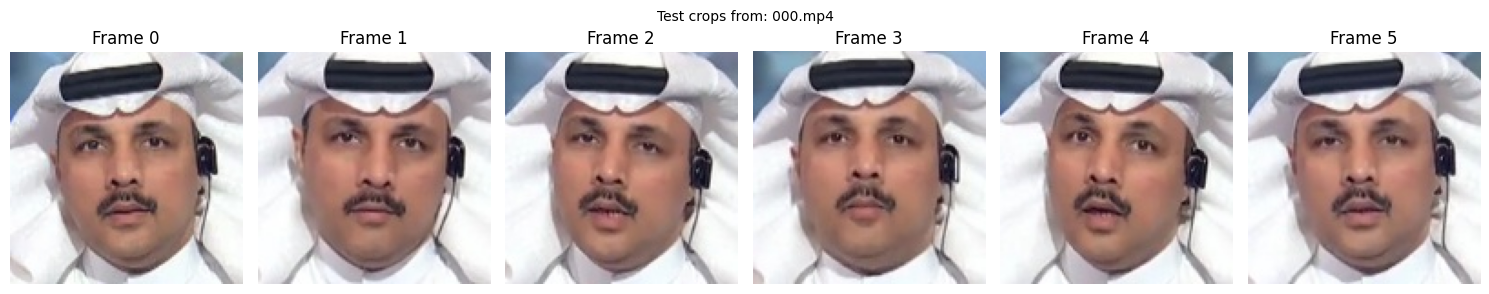

Test passed — ready for full preprocessing ✓


In [11]:
test_video = os.path.join(REAL_DIR, real_videos[0])
test_out   = os.path.join(OUT_DIR, "real", "TEST_VIDEO")

n = process_one_video(test_video, test_out, frames_per_video=6, img_size=IMG_SIZE)
print(f"Saved {n} face crops from test video")

# Show the 6 crops
import matplotlib.pyplot as plt
crops = sorted(os.listdir(test_out))
fig, axes = plt.subplots(1, len(crops), figsize=(15, 3))
for i, fname in enumerate(crops):
    img = np.array(Image.open(os.path.join(test_out, fname)))
    axes[i].imshow(img)
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")
plt.suptitle(f"Test crops from: {real_videos[0]}", fontsize=10)
plt.tight_layout()
plt.show()

# Clean up test
import shutil
shutil.rmtree(test_out)
print("Test passed — ready for full preprocessing ✓")

## Step 9 — Full Preprocessing with Progress Tracking


In [12]:
PROGRESS_FILE = os.path.join(OUT_DIR, "progress.json")

def load_progress():
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE) as f:
            return json.load(f)
    return {"real": [], "fake": []}

def save_progress(progress):
    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f, indent=2)

# Which videos to process
real_to_process = real_videos[:MAX_VIDEOS]
fake_to_process = fake_videos[:MAX_VIDEOS]

progress = load_progress()
print(f"Already done — real: {len(progress['real'])}  fake: {len(progress['fake'])}")
print(f"Remaining    — real: {MAX_VIDEOS - len(progress['real'])}  "
      f"fake: {MAX_VIDEOS - len(progress['fake'])}")
print()

for label, video_list, src_dir in [
    ("real", real_to_process, REAL_DIR),
    ("fake", fake_to_process, FAKE_DIR),
]:
    print(f"{'='*50}")
    print(f"Processing {label.upper()} videos...")
    print(f"{'='*50}")
    done = set(progress[label])

    for i, fname in enumerate(video_list):
        vid_name = os.path.splitext(fname)[0]
        if vid_name in done:
            print(f"  [{i+1:03d}/{MAX_VIDEOS}] SKIP (already done): {fname}")
            continue

        video_path = os.path.join(src_dir, fname)
        out_dir    = os.path.join(OUT_DIR, label, vid_name)
        t0         = time.time()

        n_saved = process_one_video(video_path, out_dir, FRAMES_PER_VID, IMG_SIZE)
        dt      = time.time() - t0

        progress[label].append(vid_name)
        save_progress(progress)          # save after every video
        print(f"  [{i+1:03d}/{MAX_VIDEOS}] {fname:30s}  {n_saved} frames  ({dt:.1f}s)")

print()
print("="*50)
print("PREPROCESSING COMPLETE ✓")
print(f"Real videos processed : {len(progress['real'])}")
print(f"Fake videos processed : {len(progress['fake'])}")
print(f"Data saved to         : {OUT_DIR}")

Already done — real: 0  fake: 0
Remaining    — real: 150  fake: 150

Processing REAL videos...
  [001/150] 000.mp4                         32 frames  (3.5s)
  [002/150] 001.mp4                         32 frames  (9.2s)
  [003/150] 002.mp4                         32 frames  (8.8s)
  [004/150] 003.mp4                         32 frames  (4.9s)
  [005/150] 004.mp4                         32 frames  (5.1s)
  [006/150] 005.mp4                         32 frames  (4.0s)
  [007/150] 006.mp4                         32 frames  (7.1s)
  [008/150] 007.mp4                         32 frames  (3.9s)
  [009/150] 008.mp4                         32 frames  (4.3s)
  [010/150] 009.mp4                         32 frames  (6.5s)
  [011/150] 010.mp4                         32 frames  (4.0s)
  [012/150] 011.mp4                         32 frames  (11.6s)
  [013/150] 012.mp4                         32 frames  (7.9s)
  [014/150] 013.mp4                         32 frames  (3.3s)
  [015/150] 014.mp4                 

## Step 10 — Final Check

Real video folders : 150
Fake video folders : 150
Total real frames  : 4780
Total fake frames  : 4787



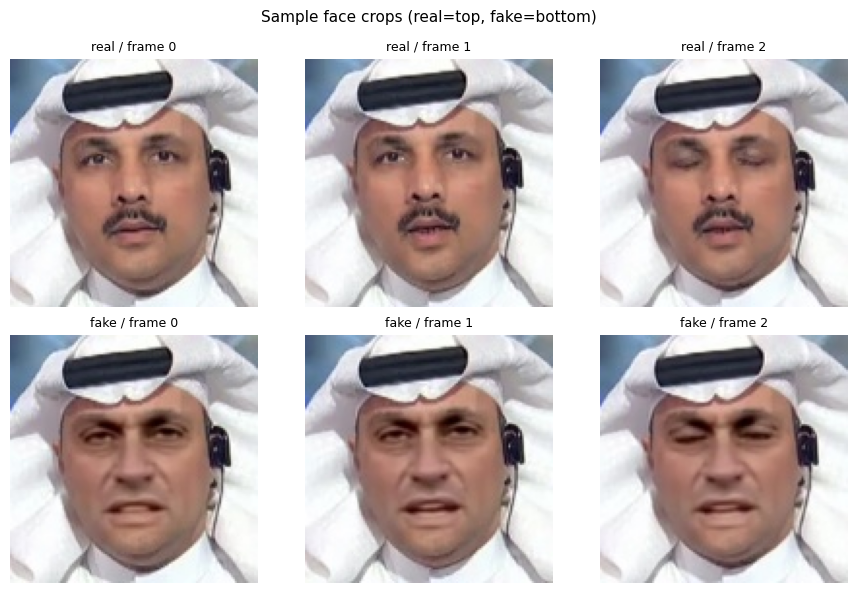


Your DATA_ROOT for train.ipynb:
  DATA_ROOT = "/content/drive/MyDrive/istvt_data"


In [13]:
real_vids = os.listdir(os.path.join(OUT_DIR, "real"))
fake_vids = os.listdir(os.path.join(OUT_DIR, "fake"))

print(f"Real video folders : {len(real_vids)}")
print(f"Fake video folders : {len(fake_vids)}")

# Count total frames
real_frames = sum(
    len(os.listdir(os.path.join(OUT_DIR, "real", v)))
    for v in real_vids
)
fake_frames = sum(
    len(os.listdir(os.path.join(OUT_DIR, "fake", v)))
    for v in fake_vids
)
print(f"Total real frames  : {real_frames}")
print(f"Total fake frames  : {fake_frames}")
print()

# Show 3 sample crops from a real and a fake video
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, (label, vids) in enumerate([("real", real_vids), ("fake", fake_vids)]):
    vid_dir = os.path.join(OUT_DIR, label, vids[0])
    frames  = sorted(os.listdir(vid_dir))[:3]
    for col, fname in enumerate(frames):
        img = np.array(Image.open(os.path.join(vid_dir, fname)))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{label} / frame {col}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Sample face crops (real=top, fake=bottom)", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nYour DATA_ROOT for train.ipynb:")
print(f'  DATA_ROOT = "{OUT_DIR}"')